In [1]:
# Import all packages that will be used for this task

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Analyze the relationship between cholesterol levels and heart attack risk, considering additional factors such as BMI, blood pressure, triglyceride levels, and lifestyle habits. What patterns indicate a stronger correlation?

Data: https://drive.google.com/file/d/13ShLPdVJdjiCsyIuif4Ih45ZUA9Zu8Zz/view?usp=sharing

In [2]:
# To Do: Find the answer to the query using code

Query 1 Answer:

### 2. Visualize how profit is distributed across different categories using a pie chart, and explode the wedge with the highest percentage of profit across all categories.

Data: https://drive.google.com/file/d/1-cCEA9WxaLbjx8MwQJUfrQOfznnE_r5k/view?usp=sharing

Query 2 Answer:

In [3]:
df = pd.read_csv("Superstore (1).csv") # Load the dataset

df.head() # Explore the dataset

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [4]:
df.info() # Look at the columns to uderstand the task

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [5]:
category_profit = df.groupby('Category')['Profit'].sum() # Group and sum thr Profit by Caterogy

category_profit

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145451.9773
Name: Profit, dtype: float64

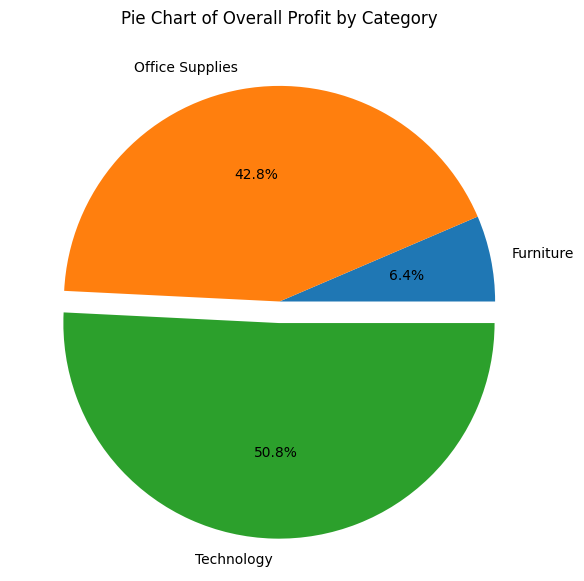

In [6]:
max_val = max(category_profit) # Find the maximum slice
explode_value = tuple([0 if i!=max_val else 0.1 for i in category_profit]) # Create an explode_value tuple to explode the maximum slice

# Creating plot
fig = plt.figure(figsize=(10, 7))
plt.pie(category_profit, labels=category_profit.index, explode=explode_value, autopct='%1.1f%%')
plt.title("Pie Chart of Overall Profit by Category")


# show plot
plt.show()

### 3. Visualize the global sales trends of Nintendo games over time using a line plot. How have Nintendo's sales figures evolved from the 1980s to the 2000s?

Data: https://drive.google.com/file/d/1IwbdhYcqMEf4zZH0Hfgbev9pCrpvJiGk/view?usp=sharing

Query 3 Answer:

In [7]:
df = pd.read_csv("vgsales_no_headers.csv", header=None) # The dataset does not have headers
df

,0,1,2,3,4,5,6,7,8,9,10
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


This dataset is very messy. We will need the wrangle this to properly create visuals  

### Step 1
The first column is simply an index, it is not needed so it will be removed

In [8]:
df = df.drop(df.columns[0], axis=1) # Remove the first column
df.info() # Inspect the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   1       16598 non-null  object 
 1   2       16598 non-null  object 
 2   3       16327 non-null  float64
 3   4       16598 non-null  object 
 4   5       16540 non-null  object 
 5   6       16598 non-null  float64
 6   7       16598 non-null  float64
 7   8       16598 non-null  float64
 8   9       16598 non-null  float64
 9   10      16598 non-null  float64
dtypes: float64(6), object(4)
memory usage: 1.3+ MB


### Step 2
We need to name the columns, however, we need to understand what each colum is. 
The first 5 columns are easy enough to interpret but the last 5 will pose some difficulty since it is all numerical data. 

On closer inspection, the last column seems to be a sum of the 4 left to it. Let us confirm this hypothesis

In [9]:
value_sums = df[6]+df[7]+df[8]+df[9] # Sum the 4 columns

(df[10] == value_sums).sum() # Count the number of values that are equal to the sums of the 4 columns

np.int64(9826)

Only 9826 values are equal to the sum of the 4 columns. Even though we have confirmed not all values are equal, there are too many equal values (59%) to disregard our hypothesis. The discrepancy is possibly as a result of data entry errors  
 
 We will check the difference between the values and the sums using 0.025 as an error margin to confirm if any values are too far away for this to simply be a data entry error

In [10]:
((abs(df[10] - value_sums))>0.025).sum() # Count the number of values that have a difference with the sums greater tha 0.025

np.int64(0)

Since all the values are too close to the sums not to be related, we will assume that column `10` is a sum of columns `6`, `7`, `8` and `9`

In [11]:
df[10] = value_sums

Now we can properly name our columns. Since `10` is a sum of columns `6`, `7`, `8` and `9`, we assume `10` is the total and the others are the sales in different regions worldwide

In [12]:
col_names = ['Title','Console','Year','Genre','Company','Region_1','Region_2','Region_3','Region_4', 'Total_Sales' ]
df.columns = col_names

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Title        16598 non-null  object 
 1   Console      16598 non-null  object 
 2   Year         16327 non-null  float64
 3   Genre        16598 non-null  object 
 4   Company      16540 non-null  object 
 5   Region_1     16598 non-null  float64
 6   Region_2     16598 non-null  float64
 7   Region_3     16598 non-null  float64
 8   Region_4     16598 non-null  float64
 9   Total_Sales  16598 non-null  float64
dtypes: float64(6), object(4)
memory usage: 1.3+ MB


### Step 3
Check for any duplicates and delete them

In [13]:
df.duplicated().sum() # Count the number of duplicat values

np.int64(1)

In [14]:
df = df.drop_duplicates() # Delete duplicate
df.info() # Inspect dataset

<class 'pandas.core.frame.DataFrame'>
Index: 16597 entries, 0 to 16597
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Title        16597 non-null  object 
 1   Console      16597 non-null  object 
 2   Year         16327 non-null  float64
 3   Genre        16597 non-null  object 
 4   Company      16539 non-null  object 
 5   Region_1     16597 non-null  float64
 6   Region_2     16597 non-null  float64
 7   Region_3     16597 non-null  float64
 8   Region_4     16597 non-null  float64
 9   Total_Sales  16597 non-null  float64
dtypes: float64(6), object(4)
memory usage: 1.4+ MB


### Step 4
Now it is time to handle null values. First we must confirm the rows with nulls

In [15]:
df.isnull().sum() # Check the number of null values in each column

Title            0
Console          0
Year           270
Genre            0
Company         58
Region_1         0
Region_2         0
Region_3         0
Region_4         0
Total_Sales      0
dtype: int64

Since `Year` is meant to be an integer value, we cannot afford to keep null values there to work with the dataset. These rows will be removed, however, in order to preserve as much of the dataset as possible we will convert the null values in `Company` to `Unknown`

In [16]:
df['Company'] = df['Company'].fillna('Unknown') # Convert the null values in Company to Unknown
df = df.dropna(how='any',axis=0) # Remove any remaining rows with null values
df.info() # Inspect dataset

<class 'pandas.core.frame.DataFrame'>
Index: 16327 entries, 0 to 16597
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Title        16327 non-null  object 
 1   Console      16327 non-null  object 
 2   Year         16327 non-null  float64
 3   Genre        16327 non-null  object 
 4   Company      16327 non-null  object 
 5   Region_1     16327 non-null  float64
 6   Region_2     16327 non-null  float64
 7   Region_3     16327 non-null  float64
 8   Region_4     16327 non-null  float64
 9   Total_Sales  16327 non-null  float64
dtypes: float64(6), object(4)
memory usage: 1.4+ MB


### Step 5
Finally, convert the `Year` to integer values

In [17]:
df['Year'] = df['Year'].astype('int64') # Convert to integer values
df.info() # Inspect dataset

<class 'pandas.core.frame.DataFrame'>
Index: 16327 entries, 0 to 16597
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Title        16327 non-null  object 
 1   Console      16327 non-null  object 
 2   Year         16327 non-null  int64  
 3   Genre        16327 non-null  object 
 4   Company      16327 non-null  object 
 5   Region_1     16327 non-null  float64
 6   Region_2     16327 non-null  float64
 7   Region_3     16327 non-null  float64
 8   Region_4     16327 non-null  float64
 9   Total_Sales  16327 non-null  float64
dtypes: float64(5), int64(1), object(4)
memory usage: 1.4+ MB


Now we can build our visuals


In [18]:
df_nintendo = df.loc[df['Company'] == 'Nintendo'] # Filter only Nintendo game sales

nintendo_sales = df_nintendo.groupby('Year')[['Region_1','Region_2','Region_3','Region_4','Total_Sales']].sum()

nintendo_sales

,Region_1,Region_2,Region_3,Region_4,Total_Sales
Year,,,,,
1983,2.32,0.46,8.10,0.08,10.96
1984,32.57,1.95,10.36,0.67,45.55
1985,32.48,4.54,12.02,0.91,49.95
1986,6.73,1.73,7.45,0.26,16.17
1987,5.13,1.18,5.46,0.18,11.95
1988,21.23,6.15,8.13,0.93,36.44
1989,39.81,7.60,15.06,1.40,63.87
1990,19.75,6.42,8.08,1.22,35.47
1991,6.95,2.47,6.22,0.33,15.97


###### Worldwide Nintendo sales

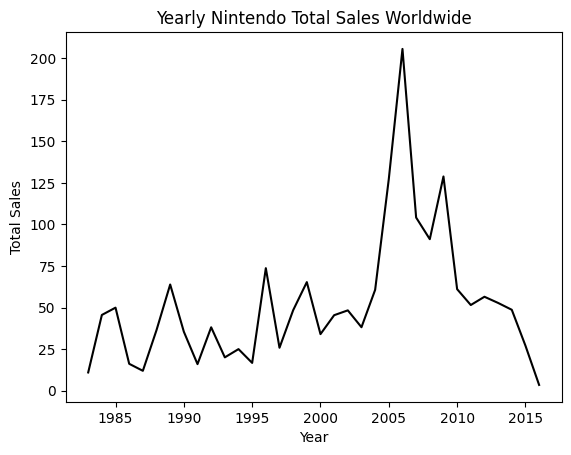

In [19]:
nintendo_sales['Total_Sales'].plot(kind='line', color = 'black')

plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.title('Yearly Nintendo Total Sales Worldwide');

###### Regional Nintendo sales

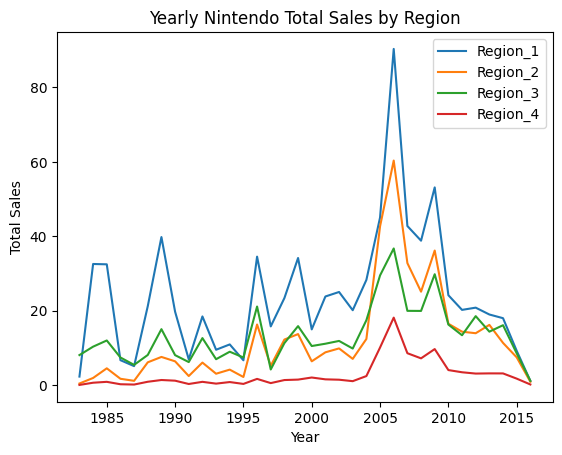

In [20]:
nintendo_sales[['Region_1','Region_2','Region_3','Region_4']].plot(kind='line')

plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.title('Yearly Nintendo Total Sales by Region');

##### Findings

1. The sales of Nintendo games every decade from the 1980's to the early 2000s is very volatile with frequent highs and lows up until 2003
2. There is a massive increase in Nintendo sales between 2004 and 2006 worldwide before falling again in 2007
3. After 2009 there is a severe decline in Nitendo game sales which they are yet to recover from in 2016
4. Region 1 has the highest Nintendo sales on average
5. Region 4 has the lowest Nintendo sales on average

### 4. In Saudi Arabia, the 5-day workweek starts on Sunday. Analyze the impact of the weekend and weekday quote dates on the quote price.

Data: https://drive.google.com/file/d/1vROMYOn9OUrIS7ChIIzkGpjeEdxm5Pe1/view?usp=sharing

Query 4 Answer:

In [21]:
df = pd.read_csv("luxury_goods_selling_transaction - quote_sell_dataset - luxury_goods_selling_transaction - quote_sell_dataset.csv")
df

,Quote ID,Product Name,Purchased Year,Luxury Brand,Selling Platform,Quote Date,Quote Price,Sold Price,Category,Condition,Status,Payment Method
0,2842302,ALEXANDER WANG Rhinestone Mesh Mini,2019,Alexander Wang,Fashionphile,2022-11-03,300.0,300.0,handbag,Pre-owned,Completed,ACH
1,2455752,BALENCIAGA Agneau Classic Hardware City,2014,Balenciaga,Fashionphile,2022-04-27,450.0,450.0,handbag,Pre-owned,Completed,Paypal
2,2455734,BALENCIAGA Chevre Gold Metallic Edge,2013,Balenciaga,Fashionphile,2022-04-26,950.0,950.0,handbag,Pre-owned,Completed,Paypal
3,18640,Baobao Issey Miyake clutch,2020,Baobao,CoutureUSA,2022-11-16,142.5,0.0,handbag,New,Seller Declined,NaN
4,18957,Burberry Nova check tote,2016,Burberry,CoutureUSA,2022-12-05,290.0,0.0,handbag,Pre-owned,Seller Declined,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
61,17954,Prada Patent Ballet Flats - Burgundy,2016,Prada,CoutureUSA,2022-10-13,55.0,0.0,shoes,Pre-owned,Seller Declined,NaN
62,2834672,TOM FORD Angela Sunglasses TF438,2020,Tom Ford,Fashionphile,2022-11-15,75.0,75.0,accessories,Pre-owned,Completed,ACH
63,2811343,VALENTINO GARAVANI Nylon Camouflage Backpack,2017,Valentino Garavani,Fashionphile,2022-10-17,100.0,100.0,handbag,Pre-owned,Completed,ACH
64,18262,Van Cleef & Arpels Vintage Alhambra pendant 18...,2019,Van Cleef & Arpels,CoutureUSA,2022-11-02,1600.0,1600.0,accessories,Pre-owned,Completed,NaN


Reformat `Quote Date` to `datetime` format and calculated columns to extract the day of the week and whether it is a weekday or not

In [22]:
df['Quote Date'] = pd.to_datetime(df['Quote Date']) # Convert to datetime
df['Quote Day'] = df['Quote Date'].dt.day_name() # Extract the day of the week
df['Day No'] = (df['Quote Date'].dt.day_of_week+1)%7 # Extract the postion of the day of the week starting with Sunday (Sunday = 0)
df['Day Type'] = df['Day No'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday') #Mark Friday and Saturday (5 and 6) as Weekends and other days as Weekdays
df.info() # Inspect dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Quote ID          66 non-null     int64         
 1   Product Name      66 non-null     object        
 2   Purchased Year    66 non-null     int64         
 3   Luxury Brand      66 non-null     object        
 4   Selling Platform  66 non-null     object        
 5   Quote Date        66 non-null     datetime64[ns]
 6   Quote Price       66 non-null     float64       
 7   Sold Price        66 non-null     float64       
 8   Category          66 non-null     object        
 9   Condition         66 non-null     object        
 10  Status            66 non-null     object        
 11  Payment Method    23 non-null     object        
 12  Quote Day         66 non-null     object        
 13  Day No            66 non-null     int32         
 14  Day Type          66 non-nul

Calculate summary statistics for the Weekdays and Weekends

In [23]:
df.groupby('Day Type')['Quote Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Day Type,,,,,,,,
Weekday,56.0,841.973214,1150.833723,0.0,270.000,440.00,685.0,5370.0
Weekend,10.0,842.900000,1043.316901,85.0,248.625,549.75,707.5,3500.0


Calculate summary statistics for each day of the week

In [24]:
day_order = df[['Day No', 'Quote Day']].drop_duplicates().sort_values('Day No')['Quote Day'] # Ensure the days are ordered correctly starting with Sunday
df.groupby('Quote Day')['Quote Price'].describe().reindex(day_order)

,count,mean,std,min,25%,50%,75%,max
Quote Day,,,,,,,,
Monday,17.0,1021.735294,1573.402445,0.0,100.00,420.00,600.00,5370.0
Tuesday,18.0,879.444444,1165.039622,75.0,331.25,445.00,695.00,4345.0
Wednesday,15.0,713.400000,712.829553,142.5,385.00,450.00,537.25,2800.0
Thursday,6.0,541.666667,579.936778,55.0,146.25,300.00,825.00,1500.0
Friday,6.0,1210.000000,1237.901450,100.0,587.50,705.00,1452.50,3500.0
Saturday,4.0,292.250000,194.212298,85.0,193.75,267.25,365.75,549.5


##### Findings
1. The average quote price on Weekdays and Weekends very close (841.97SAR and 842.9SAR respectively), however, their median quote prices differ (440.00SAR and 549.75SAR respectively) with Weekend prices being higher
2. The quote prices on Weekdays are more skewed to the right than Weekends
3. There are no sales on Sunday, implying it is a no business day
4. There are more sales on Weekdays, with the highest number on Tuesday (18)